In [1]:
import xarray as xr

In [2]:
pathUVW= '/work/bk1450/b383184/Amazon/Mercator/data/variables_c'
wfiles = f"{pathUVW}/W_1993-01c.nc"

In [3]:
W = xr.open_dataset(wfiles)
W

<xarray.Dataset> Size: 4GB
Dimensions:       (time_counter: 31, y: 499, x: 1260, depthw: 50)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 248B 1993-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB ...
    nav_lat       (y, x) float32 3MB ...
  * x             (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y             (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
  * depthw        (depthw) float32 200B 0.0 1.011 2.086 ... 5.052e+03 5.5e+03
Data variables:
    vovecrtz      (time_counter, depthw, y, x) float32 4GB ...
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Fri Nov 07 00:26:13 2025: cdo setmissval,nan W_1993-01.nc /...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

In [4]:
# w0 = (W.isel(depthw=0) == 0)*1
# W.isel(depthw=0) = w0

W = W.copy()
W['vovecrtz'].loc[dict(depthw=W.depthw.isel(depthw=0))] = 0
W

<xarray.Dataset> Size: 4GB
Dimensions:       (time_counter: 31, y: 499, x: 1260, depthw: 50)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 248B 1993-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB ...
    nav_lat       (y, x) float32 3MB ...
  * x             (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y             (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
  * depthw        (depthw) float32 200B 0.0 1.011 2.086 ... 5.052e+03 5.5e+03
Data variables:
    vovecrtz      (time_counter, depthw, y, x) float32 4GB ...
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Fri Nov 07 00:26:13 2025: cdo setmissval,nan W_1993-01.nc /...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

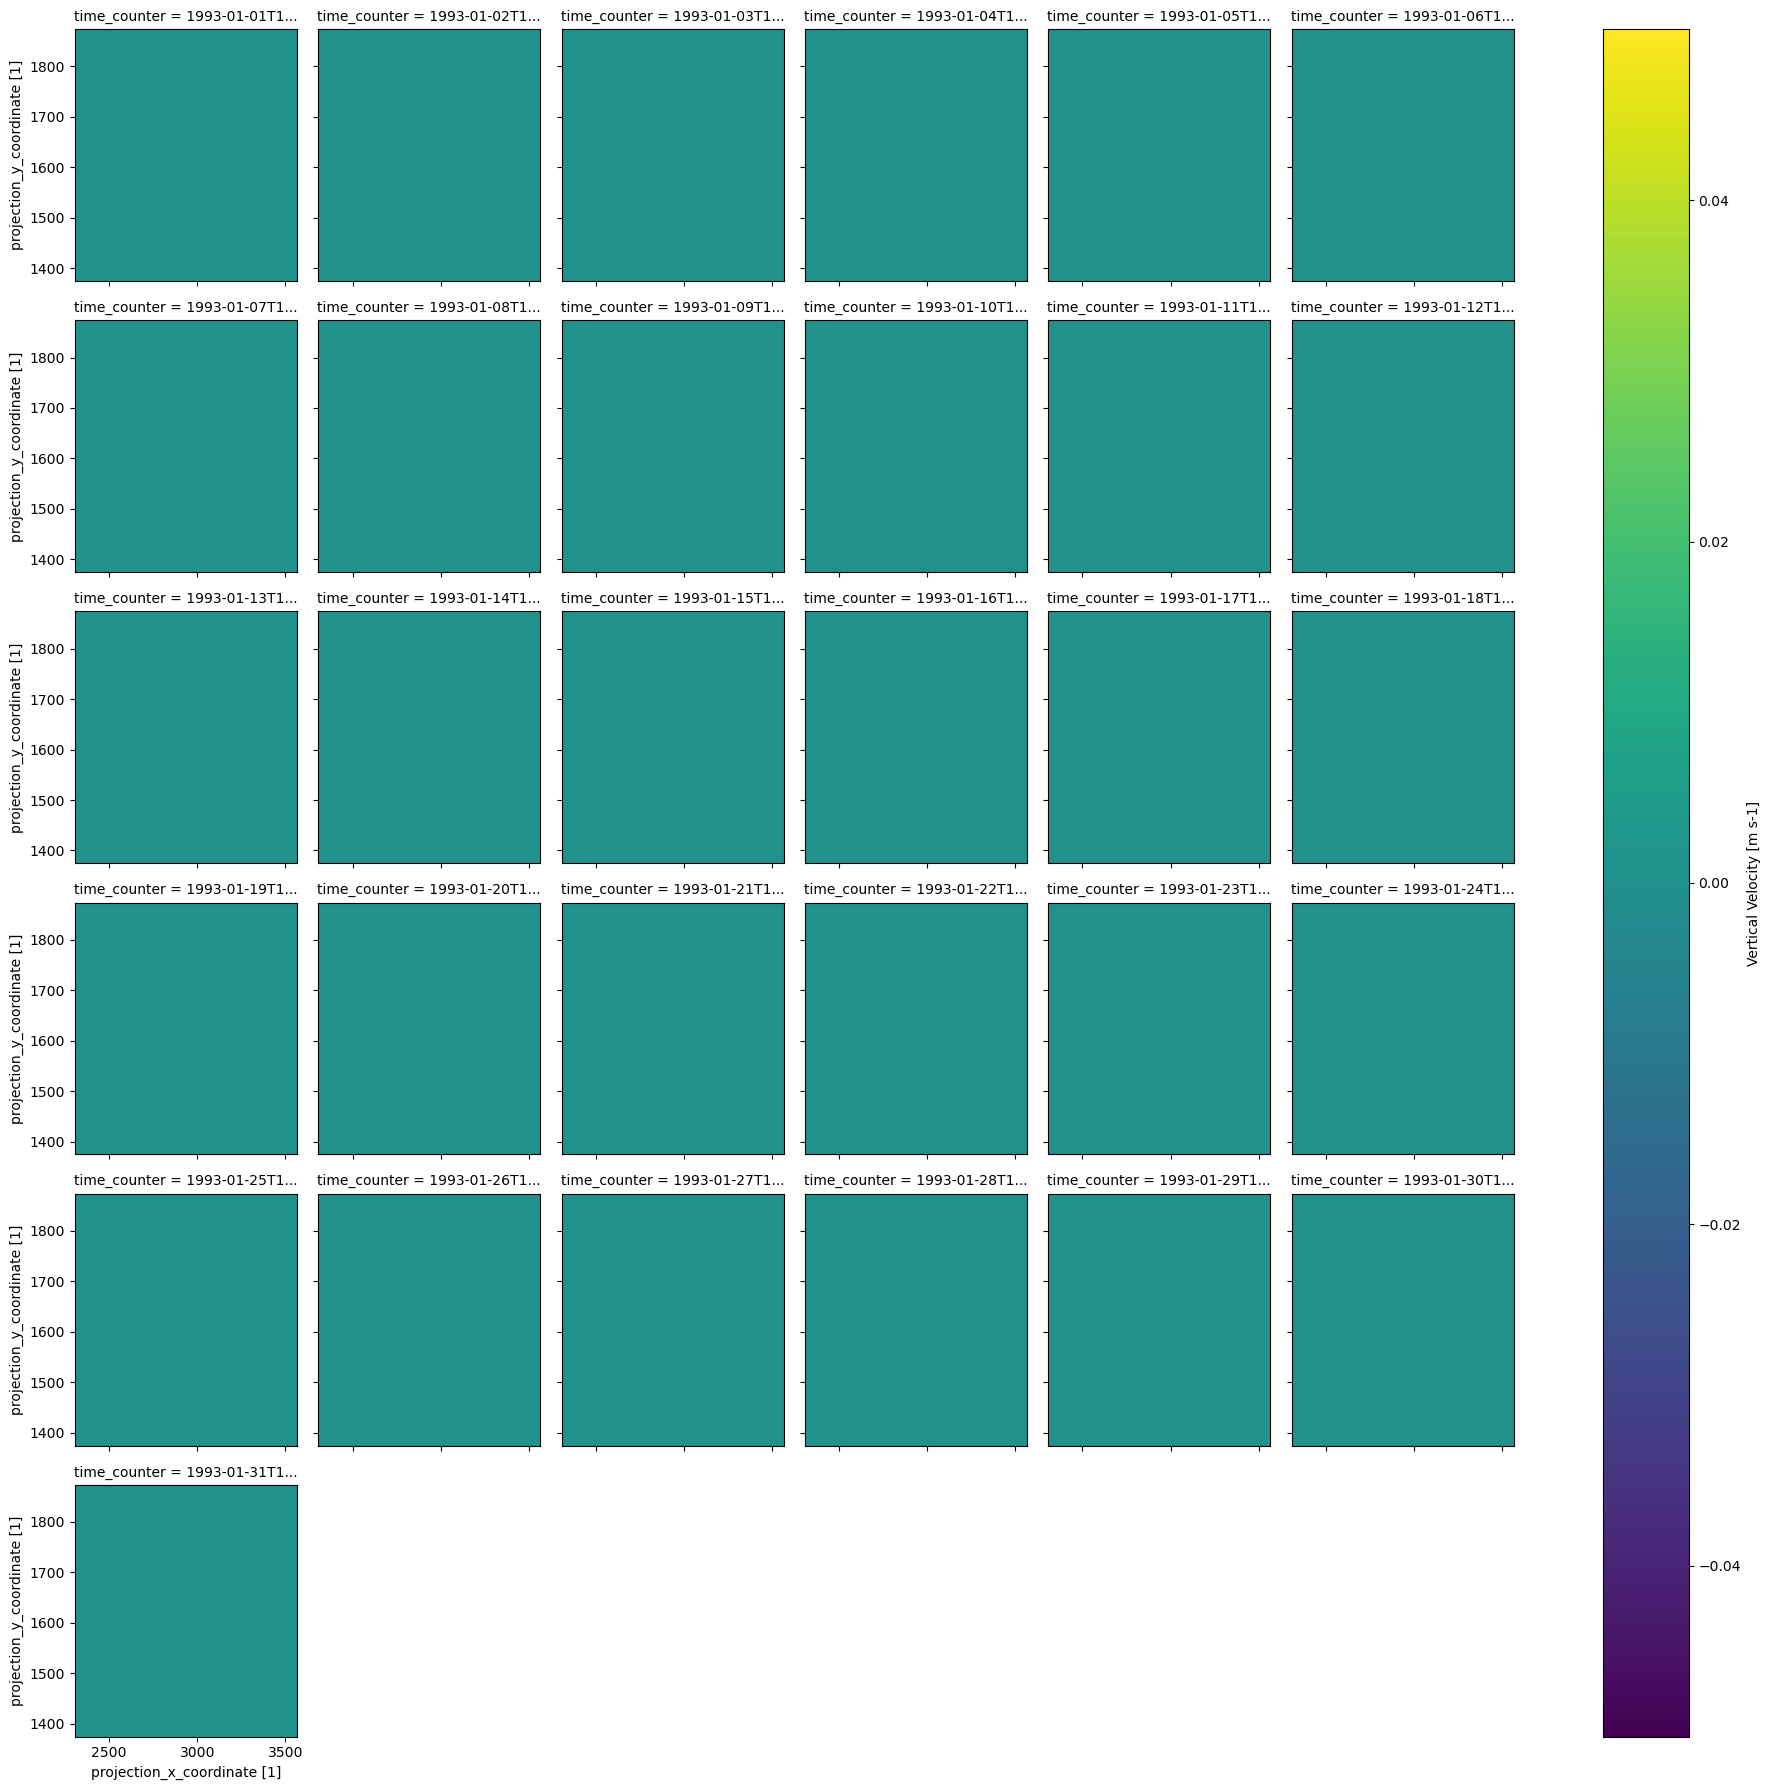

In [5]:
W.isel(depthw=0).vovecrtz.plot(col='time_counter',col_wrap=6,robust=True)

In [6]:
W.to_netcdf('W_1993-01cc.nc')

In [7]:
pwd

'/work/bk1450/b383184/Amazon/Mercator/notebooks'